# ✂️ Feature Engineering (هندسة الميزات) and Train/Test Splits
**Day 2 — Data is Everything**

---

Two of the most important skills in ML:

1. **Feature Engineering (هندسة الميزات)** — creating new, more informative columns from existing ones
2. **Train/test splits** — why we must never test a model on the same data it was trained on

These concepts connect directly: better features + proper evaluation = better models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings; warnings.filterwarnings("ignore")

# Use the Ames Housing dataset (simplified version)
np.random.seed(42)
n = 500
housing = pd.DataFrame({
    "sqft":      np.random.randint(800, 4000, n),
    "bedrooms":  np.random.randint(1, 6, n),
    "bathrooms": np.random.randint(1, 4, n),
    "age":       np.random.randint(0, 60, n),           # years since built
    "garage":    np.random.choice([0, 1], n, p=[0.3, 0.7]),  # 0=no, 1=yes
    "neighborhood_quality": np.random.randint(1, 11, n),  # 1-10 score
})
# Price: driven by size + quality + garage, with noise
housing["price"] = (
    180 * housing["sqft"]
    + 12000 * housing["bedrooms"]
    + 18000 * housing["bathrooms"]
    - 1500  * housing["age"]
    + 25000 * housing["garage"]
    + 8000  * housing["neighborhood_quality"]
    + np.random.normal(0, 30000, n)
).clip(80000).round(-3)

print("Housing dataset:", housing.shape)
print(housing.head())

Housing dataset: (500, 7)
   sqft  bedrooms  bathrooms  age  garage  neighborhood_quality     price
0  3974         1          2   29       1                     3  751000.0
1  1660         5          1   51       1                     5  329000.0
2  2094         5          2   38       1                     1  493000.0
3  1930         1          1   34       0                     7  367000.0
4  1895         5          3   17       1                     5  489000.0


## Feature Engineering (هندسة الميزات)

**Feature Engineering (هندسة الميزات)** is the process of using domain knowledge to create new features from existing ones. It often has a bigger impact on model performance than choosing a more complex algorithm.

Common techniques:
- **Ratios**: price per square foot, debt-to-income
- **Interactions**: multiply two features that together tell a story
- **Polynomial features**: square a feature to capture nonlinear effects
- **Binning**: group a continuous feature into categories

In [2]:
# Create engineered features
housing_eng = housing.copy()

# 1. Price per square foot is useful in housing
housing_eng["sqft_per_bedroom"] = (housing_eng["sqft"] / housing_eng["bedrooms"]).round(1)

# 2. House age categories (binning)
housing_eng["age_group"] = pd.cut(housing_eng["age"],
    bins=[0, 10, 25, 60], labels=["New (0-10y)", "Mid (10-25y)", "Old (25+y)"])

# 3. Total rooms (interaction)
housing_eng["total_rooms"] = housing_eng["bedrooms"] + housing_eng["bathrooms"]

# 4. Size-quality interaction (bigger house in better neighborhood)
housing_eng["size_quality"] = housing_eng["sqft"] * housing_eng["neighborhood_quality"]

print("New features created:")
print(housing_eng[["sqft", "bedrooms", "sqft_per_bedroom", "age", "age_group",
                     "total_rooms", "size_quality"]].head(8))

New features created:
   sqft  bedrooms  sqft_per_bedroom  age     age_group  total_rooms  \
0  3974         1            3974.0   29    Old (25+y)            3   
1  1660         5             332.0   51    Old (25+y)            6   
2  2094         5             418.8   38    Old (25+y)            7   
3  1930         1            1930.0   34    Old (25+y)            2   
4  1895         5             379.0   17  Mid (10-25y)            8   
5  3892         5             778.4   58    Old (25+y)            6   
6  2438         5             487.6   41    Old (25+y)            6   
7  2969         3             989.7   38    Old (25+y)            4   

   size_quality  
0         11922  
1          8300  
2          2094  
3         13510  
4          9475  
5         31136  
6         19504  
7         26721  


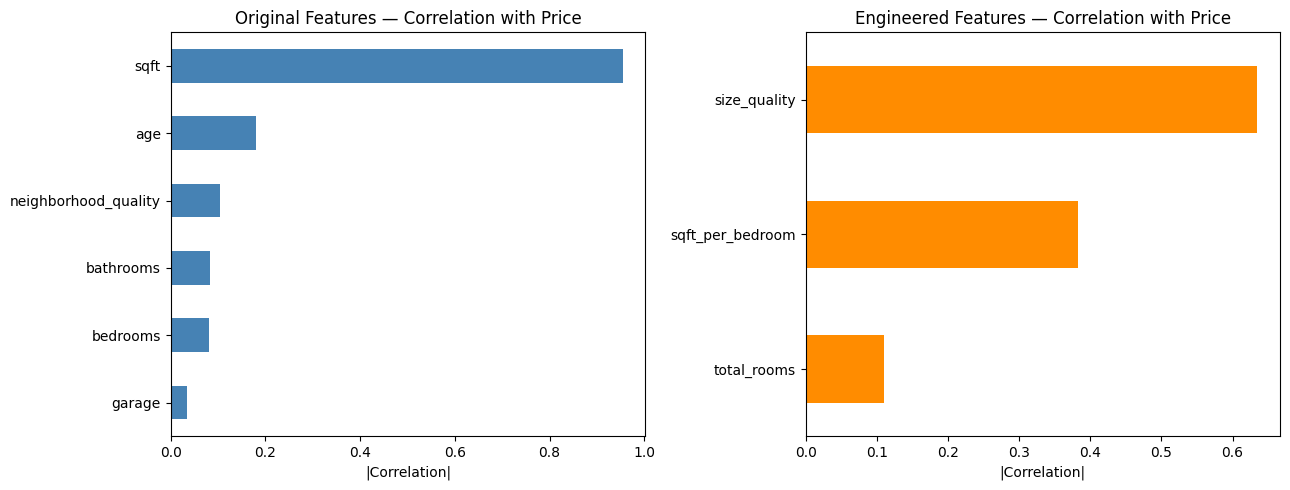

Notice: 'size_quality' (the interaction feature) often has higher correlation than either original feature alone.


In [3]:
# Compare correlation of original vs engineered features with price
original_corrs = housing[["sqft", "bedrooms", "bathrooms", "age",
                            "garage", "neighborhood_quality"]].corrwith(housing["price"])
engineered_corrs = housing_eng[["sqft_per_bedroom", "total_rooms",
                                  "size_quality"]].corrwith(housing_eng["price"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

original_corrs.abs().sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Original Features — Correlation with Price", fontsize=12)
axes[0].set_xlabel("|Correlation|")

engineered_corrs.abs().sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Engineered Features — Correlation with Price", fontsize=12)
axes[1].set_xlabel("|Correlation|")

plt.tight_layout(); plt.show()
print("Notice: 'size_quality' (the interaction feature) often has higher correlation than either original feature alone.")

---

## Train/Test Splits — Why They Matter

This is one of the most important concepts in Machine Learning (التعلم الآلي).

**The problem**: If you test your model on the same data you trained it on, you're essentially giving a student the answer key and then testing them with the same questions. The score means nothing — you can't tell if they actually *learned*.

In ML terms: a model can **memorize** training data without generalizing. We call this **overfitting**.

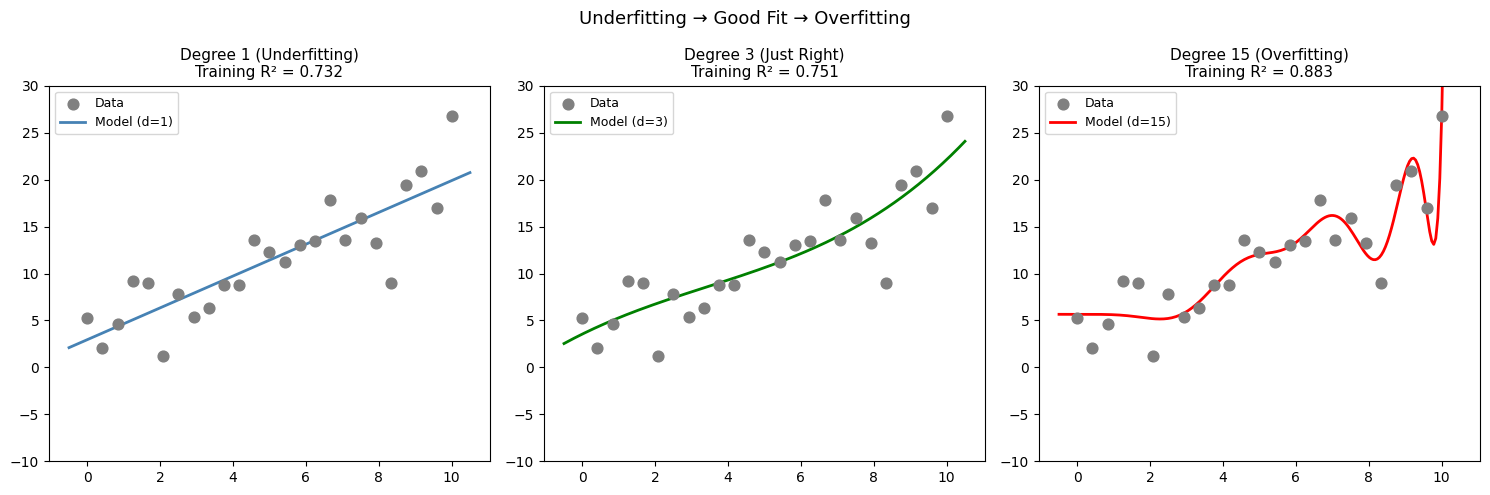

The degree-15 model fits the training data PERFECTLY (R²=1.0)
But it would fail completely on new, unseen data.


In [4]:
# Demonstrate OVERFITTING visually
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(0)
X_demo = np.linspace(0, 10, 25)
y_demo = 2 * X_demo + np.random.normal(0, 3, 25)

X_plot = np.linspace(-0.5, 10.5, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (degree, title, color) in enumerate([(1, "Degree 1 (Underfitting)", "steelblue"),
                                              (3, "Degree 3 (Just Right)",   "green"),
                                              (15, "Degree 15 (Overfitting)", "red")]):
    model_demo = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model_demo.fit(X_demo.reshape(-1, 1), y_demo)
    y_plot = model_demo.predict(X_plot)

    train_pred = model_demo.predict(X_demo.reshape(-1, 1))
    train_r2   = r2_score(y_demo, train_pred)

    axes[i].scatter(X_demo, y_demo, color="grey", s=60, zorder=5, label="Data")
    axes[i].plot(X_plot, y_plot, color=color, linewidth=2, label=f"Model (d={degree})")
    axes[i].set_ylim(-10, 30)
    axes[i].set_title(f"{title}\nTraining R² = {train_r2:.3f}", fontsize=11)
    axes[i].legend(fontsize=9)

plt.suptitle("Underfitting → Good Fit → Overfitting", fontsize=13)
plt.tight_layout(); plt.show()
print("The degree-15 model fits the training data PERFECTLY (R²=1.0)")
print("But it would fail completely on new, unseen data.")

In [5]:
# The solution: Train/Test Split
from sklearn.model_selection import train_test_split

# Prepare housing data
feature_cols = ["sqft", "bedrooms", "bathrooms", "age", "garage", "neighborhood_quality"]
X = housing[feature_cols].values
y = housing["price"].values

# Split: 80% for training, 20% for testing — RANDOM split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Total samples:", len(X))
print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X):.0%})")
print(f"Test set:     {len(X_test)} samples ({len(X_test)/len(X):.0%})")
print()
print("The test set is 'locked away' — we never use it during training.")
print("We only look at it once, at the very end, to measure real performance.")

Total samples: 500
Training set: 400 samples (80%)
Test set:     100 samples (20%)

The test set is 'locked away' — we never use it during training.
We only look at it once, at the very end, to measure real performance.


In [6]:
# Correct workflow: train on train, evaluate on test
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_s  = scaler.transform(X_test)         # transform test data using training stats

model = LinearRegression()
model.fit(X_train_s, y_train)

# Performance on training set
y_train_pred = model.predict(X_train_s)
train_r2  = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Performance on test set (what actually matters)
y_test_pred = model.predict(X_test_s)
test_r2  = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("─" * 40)
print(f"Training set  — R²: {train_r2:.3f},  RMSE: ${train_rmse:,.0f}")
print(f"Test set      — R²: {test_r2:.3f},  RMSE: ${test_rmse:,.0f}")
print("─" * 40)
print()
if abs(train_r2 - test_r2) < 0.05:
    print("✓ Training and test R² are similar — the model generalizes well")
else:
    print("⚠ Large gap between training and test performance → signs of overfitting")

────────────────────────────────────────
Training set  — R²: 0.970,  RMSE: $30,221
Test set      — R²: 0.966,  RMSE: $30,424
────────────────────────────────────────

✓ Training and test R² are similar — the model generalizes well


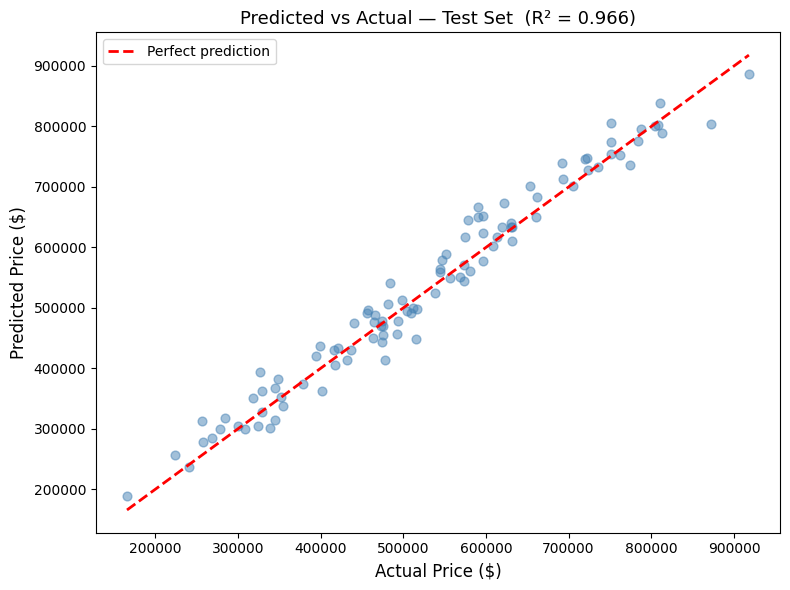

Points close to the red line = accurate predictions.
Systematic deviations = the model is missing some pattern.


In [7]:
# Visualize: predicted vs actual on test set
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, color="steelblue", s=40)
min_val, max_val = y_test.min(), y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect prediction")
plt.xlabel("Actual Price ($)", fontsize=12)
plt.ylabel("Predicted Price ($)", fontsize=12)
plt.title(f"Predicted vs Actual — Test Set  (R² = {test_r2:.3f})", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()
print("Points close to the red line = accurate predictions.")
print("Systematic deviations = the model is missing some pattern.")

---

## Key Rule: Fit on Train, Transform on Test

A subtle but critical point: when you scale features, you must:
1. `fit` the scaler ONLY on the training data (learn the mean and std from training)
2. `transform` BOTH training and test data using those learned statistics

If you fit on the entire dataset, you're letting test data information "leak" into training — this is called **data leakage** and will give you unrealistically good results.

```python
# ✅ CORRECT
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)   ← uses training mean/std

# ❌ WRONG — data leakage
scaler.fit(X_all)     ← test data influences the scaler
```

---

## ✋ Exercise

In [8]:
# Add the engineered features and compare model performance
feature_cols_eng = ["sqft", "bedrooms", "bathrooms", "age", "garage",
                     "neighborhood_quality", "total_rooms", "size_quality"]
housing_eng_clean = housing_eng[feature_cols_eng + ["price"]].dropna()

X_eng = housing_eng_clean[feature_cols_eng].values
y_eng = housing_eng_clean["price"].values

# TASK: Split X_eng and y_eng into 80/20 train/test
# X_train_eng, X_test_eng, y_train_eng, y_test_eng = ...
# YOUR CODE HERE:

# TASK: Scale, train, and evaluate a LinearRegression model
# Then print training R² and test R²
# YOUR CODE HERE:

# QUESTION: Are the engineered features improving test performance?
print("Compare your test R² to the model above (test_r2 =", round(test_r2, 3), ")")

Compare your test R² to the model above (test_r2 = 0.966 )
